Mục tiêu: Phát hiện và xử lý outlier/anomaly của Dataset 

Ngày phân tích: 2026-08-06



Step 1: Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_PATH = Path("../data/cookie_cats.csv")

df = pd.read_csv(
    DATA_PATH,
    dtype={
        "userid": "int64",
        "version": "string",
        "sum_gamerounds": "int64",
        "retention_1": "bool",
        "retention_7": "bool",
    },
)
print(f"Loaded {len(df):,} rows")

Loaded 90,189 rows


Step 2: Profile user extreme outlier

In [3]:
# Profile user có sum_gamerounds lớn nhất
# Câu hỏi: bot/emulator hay heavy user thật?

max_rounds = df["sum_gamerounds"].max()
outlier_row = df[df["sum_gamerounds"] == max_rounds]

print(f"Max sum_gamerounds: {max_rounds:,}")
print(f"Rounds per day:     {max_rounds / 14:.1f}")
print(f"Estimated hours/day (assuming 1.5 min/round): "
      f"{max_rounds / 14 * 1.5 / 60:.1f}h")
print()
print("Full record:")
print(outlier_row.to_string(index=False))
print()

# Verdict logic
r1 = outlier_row["retention_1"].values[0]
r7 = outlier_row["retention_7"].values[0]

if not r1 and not r7:
    print("Verdict: LIKELY BOT")
    print(f" → Cày {max_rounds:,} rounds trong 14 ngày nhưng không retention D1 hay D7")
    print(" → Bot/emulator/QA account pattern rõ ràng")
elif r1 and r7:
    print("Verdict: POSSIBLY HEAVY HUMAN USER")
    print(" → Có retention → có behavior giống người dùng thật")
    print(" → Vẫn nên flag, không quyết vội")
else:
    print("Verdict: AMBIGUOUS")
    print(" → Cần review thủ công")

Max sum_gamerounds: 49,854
Rounds per day:     3561.0
Estimated hours/day (assuming 1.5 min/round): 89.0h

Full record:
 userid version  sum_gamerounds  retention_1  retention_7
6390605 gate_30           49854        False         True

Verdict: AMBIGUOUS
 → Cần review thủ công


Step 3: Đếm số lượng user theo các mốc

In [7]:
# Bao nhiêu user vượt các mốc khác nhau?
# Breakdown theo version để check imbalance ẩn

thresholds =    [
    ("p99.9 (~493 rounds)", df["sum_gamerounds"].quantile(0.999)),
    ("1,000 rounds (~71/day)", 1000),
    ("3,000 rounds (~214/day)", 3000),
    ("10,000 rounds", 10000),
]

results = []
for label, thr in thresholds:
        subset = df[df["sum_gamerounds"] > thr]
        n_total = len(subset)
        n_g30 = (subset["version"] == "gate_30").sum()
        n_g40 = (subset['version'] == "gate_40").sum()
        results.append({
            "threshold": label,
            "n_total": n_total,
            "n_gate_30": n_g30,
            "n_gate_40": n_g40,
        })

threshold_table = pd.DataFrame(results)
print("User count above thresholds:")
print(threshold_table.to_string(index=False))

User count above thresholds:
              threshold  n_total  n_gate_30  n_gate_40
    p99.9 (~493 rounds)       91         41         50
 1,000 rounds (~71/day)      116         53         63
3,000 rounds (~214/day)        1          1          0
          10,000 rounds        1          1          0


Step 4: Vẽ Boxplot

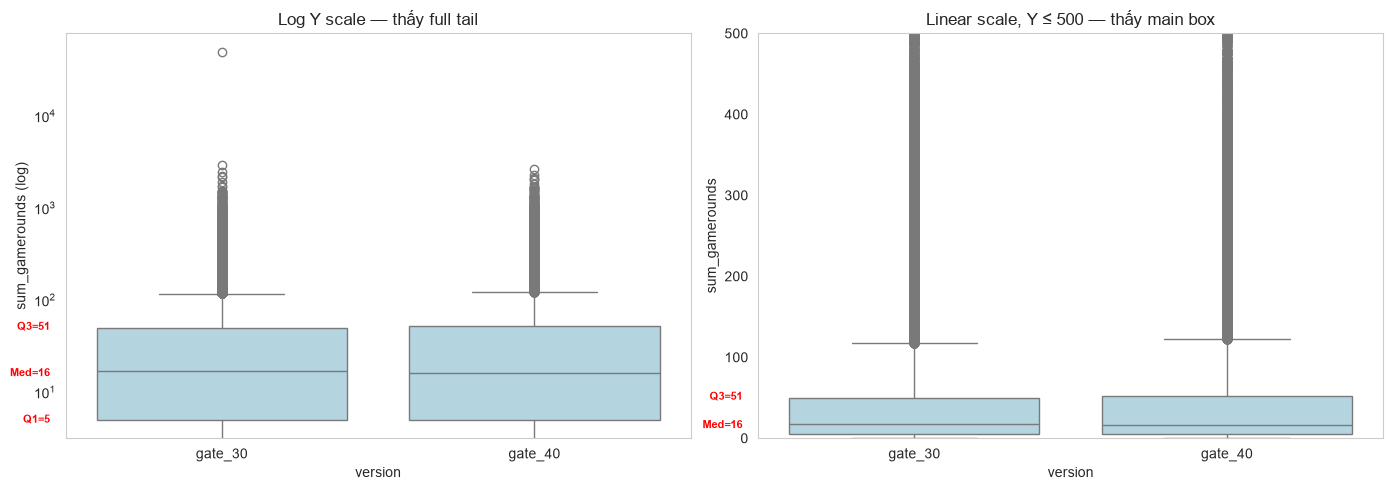

In [16]:
from matplotlib.ticker import FixedLocator

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tính percentile 1 lần (dùng chung toàn dataset)
q1 = df["sum_gamerounds"].quantile(0.25)
med = df["sum_gamerounds"].quantile(0.50)
q3 = df["sum_gamerounds"].quantile(0.75)

# ---- Left: log scale — hiện đủ Q1, Med, Q3 ----
sns.boxplot(data=df, x="version", y="sum_gamerounds", ax=axes[0], color="lightblue")
axes[0].set_yscale("log")
axes[0].set_title("Log Y scale — thấy full tail")
axes[0].set_ylabel("sum_gamerounds (log)")
axes[0].grid(False)

left_ticks = [q1, med, q3]
left_labels = [f"Q1={q1:.0f}", f"Med={med:.0f}", f"Q3={q3:.0f}"]

axes[0].yaxis.set_minor_locator(FixedLocator(left_ticks))
axes[0].tick_params(axis="y", which="minor", length=6, color="red", width=1.5)

for t, lbl in zip(left_ticks, left_labels):
    axes[0].text(-0.55, t, lbl, va="center", ha="right",
                 fontsize=8, color="red", fontweight="bold")

# ---- Right: linear scale, cap Y ở 500 — bỏ Q1, chỉ hiện Med và Q3 ----
sns.boxplot(data=df, x="version", y="sum_gamerounds", ax=axes[1], color="lightblue")
axes[1].set_ylim(0, 500)
axes[1].set_title("Linear scale, Y ≤ 500 — thấy main box")
axes[1].set_ylabel("sum_gamerounds")
axes[1].grid(False)

right_ticks = [med, q3]
right_labels = [f"Med={med:.0f}", f"Q3={q3:.0f}"]

axes[1].yaxis.set_minor_locator(FixedLocator(right_ticks))
axes[1].tick_params(axis="y", which="minor", length=6, color="red", width=1.5)

for t, lbl in zip(right_ticks, right_labels):
    axes[1].text(-0.55, t, lbl, va="center", ha="right",
                 fontsize=8, color="red", fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/phase2_boxplot_minor_ticks.png", dpi=120, bbox_inches="tight")
plt.show()

Step 5: Logical consistency check 

In [17]:
# Cross-tab: version × retention_1 × retention_7
# Bảng 2×2×2 = 8 cells. Cell = 0 hoặc rất ít → impossible/edge case

crosstab = df.groupby(
    ["version", "retention_1", "retention_7"],
    observed=True,
).size().reset_index(name="n")

crosstab["pct_of_version"] = (
    crosstab.groupby("version", observed=True)["n"]
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

print("Cross-tab: version × retention_1 × retention_7")
print(crosstab.to_string(index=False))
print()

# Extra: chỉ nhìn nhóm retention_7=True nhưng retention_1=False
r7_not_r1 = df[(df["retention_7"] == True) & (df["retention_1"] == False)]
print(f"\nUsers retention_7=True nhưng retention_1=False: {len(r7_not_r1):,}")
print(f"  Median sum_gamerounds: {r7_not_r1['sum_gamerounds'].median()}")
print(f"  Mean sum_gamerounds:   {r7_not_r1['sum_gamerounds'].mean():.1f}")
print("→ Nếu median thấp → group này chỉ 'skip D1 rồi quay lại D7 xem thử' — bình thường")

Cross-tab: version × retention_1 × retention_7
version  retention_1  retention_7     n  pct_of_version
gate_30        False        False 22840           51.10
gate_30        False         True  1826            4.09
gate_30         True        False 13358           29.88
gate_30         True         True  6676           14.94
gate_40        False        False 23597           51.87
gate_40        False         True  1773            3.90
gate_40         True        False 13613           29.93
gate_40         True         True  6506           14.30


Users retention_7=True nhưng retention_1=False: 3,599
  Median sum_gamerounds: 45.0
  Mean sum_gamerounds:   88.0
→ Nếu median thấp → group này chỉ 'skip D1 rồi quay lại D7 xem thử' — bình thường


Step 6: Sensitivity check

In [18]:
# Sensitivity: outlier ảnh hưởng metric bao nhiêu?
# Compare 3 phiên bản dataset:
#   (1) Full
#   (2) Loại > 3,000 rounds  
#   (3) Loại > 1,000 rounds

def compute_metrics(data: pd.DataFrame, label: str) -> pd.DataFrame:
    """Tính retention rates + mean/median rounds theo version."""
    result = data.groupby("version").agg(
        n_users=("userid", "count"),
        retention_1_rate=("retention_1", "mean"),
        retention_7_rate=("retention_7", "mean"),
        mean_rounds=("sum_gamerounds", "mean"),
        median_rounds=("sum_gamerounds", "median"),
    ).round(4)
    result["dataset"] = label
    return result.reset_index()


metrics_full = compute_metrics(df, "Full dataset")
metrics_no_3k = compute_metrics(df[df["sum_gamerounds"] <= 3000], "Excl. >3,000 rounds")
metrics_no_1k = compute_metrics(df[df["sum_gamerounds"] <= 1000], "Excl. >1,000 rounds")

sensitivity_table = pd.concat([metrics_full, metrics_no_3k, metrics_no_1k], ignore_index=True)
sensitivity_table = sensitivity_table[[
    "dataset", "version", "n_users",
    "retention_1_rate", "retention_7_rate",
    "mean_rounds", "median_rounds",
]]

print("Sensitivity check — impact của outlier lên metric chính:")
print(sensitivity_table.to_string(index=False))
print()

# Chênh lệch retention giữa 3 dataset
for metric in ["retention_1_rate", "retention_7_rate"]:
    print(f"\n{metric} — thay đổi khi loại outlier:")
    pivot = sensitivity_table.pivot(index="version", columns="dataset", values=metric)
    print(pivot)

Sensitivity check — impact của outlier lên metric chính:
            dataset version  n_users  retention_1_rate  retention_7_rate  mean_rounds  median_rounds
       Full dataset gate_30    44700            0.4482            0.1902      52.4563           17.0
       Full dataset gate_40    45489            0.4423            0.1820      51.2988           16.0
Excl. >3,000 rounds gate_30    44699            0.4482            0.1902      51.3421           17.0
Excl. >3,000 rounds gate_40    45489            0.4423            0.1820      51.2988           16.0
Excl. >1,000 rounds gate_30    44647            0.4476            0.1892      49.8258           17.0
Excl. >1,000 rounds gate_40    45426            0.4416            0.1809      49.5296           16.0


retention_1_rate — thay đổi khi loại outlier:
dataset  Excl. >1,000 rounds  Excl. >3,000 rounds  Full dataset
version                                                        
gate_30               0.4476               0.4482        0.4

Step 7: Chốt Policy

In [19]:
# Outlier Policy Decision

print("="*60)
print("OUTLIER POLICY DECISION")
print("="*60)
print("""
Chosen: Remove 1 user extreme nhất, giữ toàn bộ còn lại

Threshold: sum_gamerounds > 10,000
  → Loại 1 user (userid của user 49,854 rounds)
  → Giữ 90,188 users để phân tích

Rationale:
  1. Chỉ user 49,854 rounds có bằng chứng bot MẠNH:
     - ~3,561 rounds/ngày = 89h chơi/ngày → bất khả thi
     - Boxplot: cách cluster outliers khác 1 order of magnitude
     - Threshold table: user duy nhất vượt 10K rounds
  2. Các "outlier" khác (1,000-3,000 rounds) là AMBIGUOUS:
     - Có thể bot ẩn, có thể human heavy addict
     - Không có evidence phân biệt → default là trust data
  3. Retention binary → 1 user tác động 0.002 pp trên retention rate
     → Việc keep/remove các user 500-3,000 rounds gần như không đổi kết luận
  4. Loại data tối thiểu = ít risk audit hơn
     → Chỉ cần defend 1 user duy nhất

Trade-off được chấp nhận:
  - Có thể còn bot ẩn dưới 10K rounds mà không loại được
  - Impact lên retention rate: negligible
  - Nếu stakeholder query, honest answer: "không chắc, nhưng impact nhỏ"
""")

# Apply threshold để preview
OUTLIER_THRESHOLD = 10000
outlier_removed = df[df["sum_gamerounds"] > OUTLIER_THRESHOLD]
n_removed = len(outlier_removed)
n_kept = len(df) - n_removed

print(f"Preview:")
print(f"  Threshold:            sum_gamerounds > {OUTLIER_THRESHOLD:,}")
print(f"  Rows to remove:       {n_removed}")
print(f"  Rows to keep:         {n_kept:,}")
print(f"  % of dataset removed: {n_removed/len(df)*100:.4f}%")
print()
print("User(s) being removed:")
print(outlier_removed.to_string(index=False))

OUTLIER POLICY DECISION

Chosen: Remove 1 user extreme nhất, giữ toàn bộ còn lại

Threshold: sum_gamerounds > 10,000
  → Loại 1 user (userid của user 49,854 rounds)
  → Giữ 90,188 users để phân tích

Rationale:
  1. Chỉ user 49,854 rounds có bằng chứng bot MẠNH:
     - ~3,561 rounds/ngày = 89h chơi/ngày → bất khả thi
     - Boxplot: cách cluster outliers khác 1 order of magnitude
     - Threshold table: user duy nhất vượt 10K rounds
  2. Các "outlier" khác (1,000-3,000 rounds) là AMBIGUOUS:
     - Có thể bot ẩn, có thể human heavy addict
     - Không có evidence phân biệt → default là trust data
  3. Retention binary → 1 user tác động 0.002 pp trên retention rate
     → Việc keep/remove các user 500-3,000 rounds gần như không đổi kết luận
  4. Loại data tối thiểu = ít risk audit hơn
     → Chỉ cần defend 1 user duy nhất

Trade-off được chấp nhận:
  - Có thể còn bot ẩn dưới 10K rounds mà không loại được
  - Impact lên retention rate: negligible
  - Nếu stakeholder query, honest answer: 